In [3]:
import matplotlib.pyplot as plt
from matplotlib import ticker
plt.rcParams.update({'font.size': 16})  # Sets all text to 18pt

import numpy as np
import sys
import os
ev = 27.2114079527 # Hartree
ZDirection = [0.04687, 0.13027, 0.99037]
XDirection = [ 0.998901  , -0.00611247, -0.04646972]
YDirection = [-1.41513599e-19,  9.91459712e-01, -1.30413337e-01]
def magicFormatter(x,pos):
    mantissa = f"{x:.1e}".split("e")[0]
    if (x < 1):
        if (abs(x == 0)):
            exponent = "0"
            return f"$0$"
        else:
            exponent = f"{x:.1e}".split("e")[1]
            exponent = exponent[0] + exponent[1:].lstrip("0")
    if (x > 1):
        exponent = f"{x:.1e}".split("e")[1]
        exponent = exponent.lstrip("0")
    return f"${mantissa} \\times 10^{{{exponent}}}$"

def plotDensity(outputName):
    if not os.path.isfile(outputName + "ElectronDensity.npz"):
        print(f"Cannot find file{outputName + "ElectronDensity.npz"}")
        return
    npzFile = np.load(outputName + "ElectronDensity.npz")
    compDensity = npzFile["compDensity"]
    Density = npzFile["Density"]
    positions = npzFile["positions"]
    OrbLabels = npzFile["OrbLabels"]
    project = npzFile["project"]


    NAlpha = Density[::2]
    NBeta = Density[1::2]    
    
    print(f"Net Polarisation:{np.sum(NAlpha-NBeta)}")

    plt.plot(positions,NAlpha,label="N Alpha")
    plt.plot(positions,NBeta,label="N Beta")
    plt.xticks(positions,OrbLabels)
    #plt.ylim(0,1.1)
    plt.legend()
    with open(outputName + "ElectronDensity.png","wb") as f:
        plt.savefig(f,dpi=400)
    # plt.show()


    # plt.plot(positions,NAlpha-NBeta,label="Alpha-Beta")
    # plt.xticks(positions,OrbLabels)
    
    # plt.legend()
    # plt.show()


    

def plotSpinDensity(outputName, electronDensity,OrbLabels, AtomProjectionName,GfuncCalc):
    sigmaX = np.array([[0,1],[1,0]])
    sigmaY = np.array([[0,-1j],[1j,0]])
    sigmaZ = np.array([[1,0],[0,-1]])
    sigmaI = np.identity(2)
    
    if electronDensity is None:
        if not os.path.isfile(outputName + "ElectronSpinDensity.npz"):
            print(f"Cannot find file{outputName + "ElectronSpinDensity.npz"}")
            return
        npzFile = np.load(outputName + "ElectronSpinDensity.npz")
        compDensity = npzFile["compDensity"]
        positions = npzFile["positions"]
        OrbLabels = npzFile["OrbLabels"]
        spatialProject = npzFile["spatialProject"]
    else:
        raise ValueError("NoCalc")
    
    

    xDensityDiff = np.real(np.einsum("qp,ipq -> i",sigmaX,compDensity))
    yDensityDiff = np.real(np.einsum("qp,ipq -> i",sigmaY,compDensity))
    zDensityDiff = np.real(np.einsum("qp,ipq -> i",sigmaZ,compDensity))
    Density = np.real(np.einsum("qp,ipq -> i",sigmaI,compDensity))
    if (spatialProject is None):
        spatialProject = np.identity(len(xDensityDiff))
        spatialInvProject = np.identity(len(xDensityDiff))
    else:
        xDensityDiff = np.einsum("ji,j->i",spatialProject,xDensityDiff)
        yDensityDiff = np.einsum("ji,j->i",spatialProject,yDensityDiff)
        zDensityDiff = np.einsum("ji,j->i",spatialProject,zDensityDiff)
        Density = np.einsum("ji,j->i",spatialProject,Density)
        


    plt.plot(positions,xDensityDiff,label="X component")
    plt.plot(positions,yDensityDiff,label="Y component")
    plt.plot(positions,zDensityDiff,label="Z component")
    plt.xticks(positions,OrbLabels)
    #plt.ylim(0,1.1)
    plt.legend()
    
    plt.show()
    

    

def plotEnergySpectralDensity(outputName, numSpatialOrbitals, ERange, spectralDensity, AtomProjectionName,GfuncCalc,OrbLabels):
    if (spectralDensity is None):
        if not os.path.isfile(outputName + "SpectralDensityOfStates.npz"):
            print(f"Cannot find file{outputName + "SpectralDensityOfStates.npz"}")
            return
        npzFile = np.load(outputName + "SpectralDensityOfStates.npz",)
        positions = npzFile["positions"]
        linESpace = npzFile["linESpace"]
        OrbLabels = npzFile["OrbLabels"]
        E = npzFile["E"]
        R = npzFile["R"]
        AESW = npzFile["AESW"]
        AE = npzFile["AE"]
    else:
        raise ValueError("NoCalc")
        
    
    smallestValue = 1e-5#np.min(AE) # probably negative
    smallestValue = abs(smallestValue)

    NAlpha = np.array([[AE[idx][2*r].real if AE[idx][2*r].real > smallestValue else smallestValue for r in positions] for idx in range(len(linESpace))]).T  
    NBeta = np.array([[AE[idx][2*r+1].real if AE[idx][2*r+1].real > smallestValue else smallestValue for r in positions] for idx in range(len(linESpace))]).T  

    
    fig, axs = plt.subplots(3)
    img1 = axs[0].contourf(R, E, NAlpha, 100,locator=ticker.LogLocator(),cmap=plt.cm.inferno)
    img2 = axs[1].contourf(R, E, NBeta, 100,locator=ticker.LogLocator(),cmap=plt.cm.inferno)
    img3 = axs[2].contourf(R, E, NAlpha-NBeta, 100,cmap=plt.cm.inferno)
    axs[0].set_xticks(positions,OrbLabels)
    axs[1].set_xticks(positions,OrbLabels)
    axs[2].set_xticks(positions,OrbLabels)

    fig.colorbar(img1)
    fig.colorbar(img2)
    fig.colorbar(img3)

    # for Eigval in np.linalg.eigvals(HamMatrix):
    #     plt.axhline(y = Eigval, color = 'r', linestyle = '-') 
    axs[1].set_xlabel("Position ith site")
    axs[1].set_ylabel("Energy")
    
    plt.show()


def plotEnergyDensity(outputName, numSpatialOrbitals, ERange, electronDensity, AtomProjectionName, GfuncCalc,OrbLabels):
    if (electronDensity is None):
        if not os.path.isfile(outputName + "ElectronSpectralDensity.npz"):
            print(f"Cannot find file{outputName + "ElectronSpectralDensity.npz"}")
            return
        npzFile = np.load(outputName + "ElectronSpectralDensity.npz",)
        positions = npzFile["positions"]
        linESpace = npzFile["linESpace"]
        OrbLabels = npzFile["OrbLabels"]
        E = npzFile["E"]
        R = npzFile["R"]
        nESW = npzFile["nESW"]
        nE = npzFile["nE"]
    else:
        raise ValueError("NoCalc")
        
    
    smallestValue = 1e-5#np.min(nE)
    smallestValue = abs(smallestValue)

    NAlpha = np.array([[nE[idx][2*r].real  if nE[idx][2*r].real > smallestValue else smallestValue  for r in positions] for idx in range(len(linESpace))]).T  
    NBeta = np.array([[nE[idx][2*r+1].real if nE[idx][2*r+1].real > smallestValue else smallestValue for r in positions] for idx in range(len(linESpace))]).T  

    fig, axs = plt.subplots(3)
    #print(f"minNAlpha:{np.min(NAlpha)}")

    img1 = axs[0].contourf(R, E, NAlpha, 100,locator=ticker.LogLocator(),cmap=plt.cm.inferno)
    img2 = axs[1].contourf(R, E, NBeta, 100,locator=ticker.LogLocator(),cmap=plt.cm.inferno)
    img3 = axs[2].contourf(R, E, NAlpha-NBeta, 100,cmap=plt.cm.inferno)
    
    axs[0].set_xticks(positions,OrbLabels)
    axs[1].set_xticks(positions,OrbLabels)
    axs[2].set_xticks(positions,OrbLabels)
    
    fig.colorbar(img1)
    fig.colorbar(img2)
    fig.colorbar(img3)

    # for Eigval in np.linalg.eigvals(HamMatrix):
    #     plt.axhline(y = Eigval, color = 'r', linestyle = '-') 
    axs[1].set_xlabel("Position ith site")
    axs[1].set_ylabel("Energy")

    plt.show()


def plotdivCurrentE(outputName, label1, label2):
    if not os.path.isfile(outputName + "DiviE.npz"):
        print(f"Cannot find file{outputName + "DiviE.npz"}")
        return
    npzFile = np.load(outputName + "DiviE.npz")
    ESpace = npzFile["ESpace"]
    ESpace = ESpace * ev - 5.9 + 0.15*ev
    I1Alpha = npzFile["I1Alpha"]
    I1Beta = npzFile["I1Beta"]
    if "I2Alpha" in npzFile:
        I2Alpha = npzFile["I2Alpha"]
        I2Beta = npzFile["I2Beta"]
        twoLeads = True
    else:
        twoLeads = False
    
  
    plt.plot(ESpace,np.sum(I1Alpha,axis=1),label=f"{label1} Up")
    plt.plot(ESpace,np.sum(I1Beta,axis=1),label=f"{label1} Down")
    if (twoLeads):
        plt.plot(ESpace,np.sum(I2Alpha,axis=1),label=f"{label2} Up")
        plt.plot(ESpace,np.sum(I2Beta,axis=1),label=f"{label2} Down")

    # plt.plot(ESpace,ISO[:,0],label="ISO-0")
    # plt.plot(ESpace,ISO[:,1],label="ISO-1")
    plt.xlim(-2,0.2)
    plt.xlabel("E-Ef (ev)")
    plt.legend()
    #plt.show()
    
def plotSpinPoldivCurrentE(outputName, label1, label2,PlotI1=False, PlotI2 = True):
    #Spin difference plot
    
    if not os.path.isfile(outputName + "DiviE.npz"):
        print(f"Cannot find file{outputName + "DiviE.npz"}")
        return
    npzFile = np.load(outputName + "DiviE.npz")
    ESpace = npzFile["ESpace"]
    ESpace = ESpace * ev - 5.9 + 0.15*ev
    I1Alpha = npzFile["I1Alpha"]
    I1Beta = npzFile["I1Beta"]
    if "I2Alpha" in npzFile:
        I2Alpha = npzFile["I2Alpha"]
        I2Beta = npzFile["I2Beta"]
        twoLeads = True
    else:
        twoLeads = False

    
    I1Sum = np.sum(I1Alpha+I1Beta,axis=1)
    I1Polarisation  = np.zeros_like(I1Sum)
    np.divide(np.sum(I1Alpha-I1Beta,axis=1),I1Sum,out=I1Polarisation,where=np.abs(I1Sum) > 1e-6)
    if PlotI1:
        plt.plot(ESpace,100*I1Polarisation,label=label1)
    if (twoLeads and PlotI2):
        I2Sum = np.sum(I2Alpha+I2Beta,axis=1)
        I2Polarisation  = np.zeros_like(I2Sum)
        np.divide(np.sum(I2Alpha-I2Beta,axis=1),I2Sum,out=I2Polarisation,where=np.abs(I2Sum) > 1e-6)
        plt.plot(ESpace,100*I2Polarisation,label=label2)
    plt.ylabel("Spin Polarisation %")
    plt.xlim(-2,0.2)
    plt.xlabel("E-Ef (ev)")
    # plt.plot(ESpace,ISO[:,0],label="ISO-0")
    # plt.plot(ESpace,ISO[:,1],label="ISO-1")
    
    plt.legend()
    #plt.show()



In [8]:
def makePlots():
    #Generate the plots from files
    outputName = sys.argv[1]
    print(f"Loading data from: {outputName}")

    plotdivCurrentE(outputName+ "PE")
    plotdivCurrentE(outputName+ "PE2")
    plotdivCurrentE(outputName)
        
    plotEnergySpectralDensity(outputName)
    plotEnergyDensity(outputName)
    plotDensity(outputName)

All these Calculations were done with:

Spin polarisation of 4% along z direction in both copper and Photoelectrons

Gamma = 1e-2 for Copper / Scattering

Gamma = 0 for other atoms

Gamma = 1e-4 for PhotoElectrons

mu = 5.9ev Above muLeft

muLeft =-0.15  ---- Chemical potential at zero interaction

QCHEM Energy:-3076.941442288752
RHF Energy: ? - Not forcing self adjoint self energy
Spin Polarised Energy: -3076.388379849178
No Electrons =  328.0062495950101606
Perfect number of electrons = 328

With PhotoElectrons:
E:       -3075.493738397651
No. Elec: 327.5446989784466609

Convergence: 
DDIIS: Density diff norm: < 5e-10. 
CDIIS: ?


Doing `HF' with a Gamma = 1e-6

Thermal Energy: ?

No Electrons = ?

PYSCF Energy with QCHEM Density: -3077.075060361728 - Solution is very sensitive to density, ~ DDIIS 1e-5 errors due to saving and loading. 


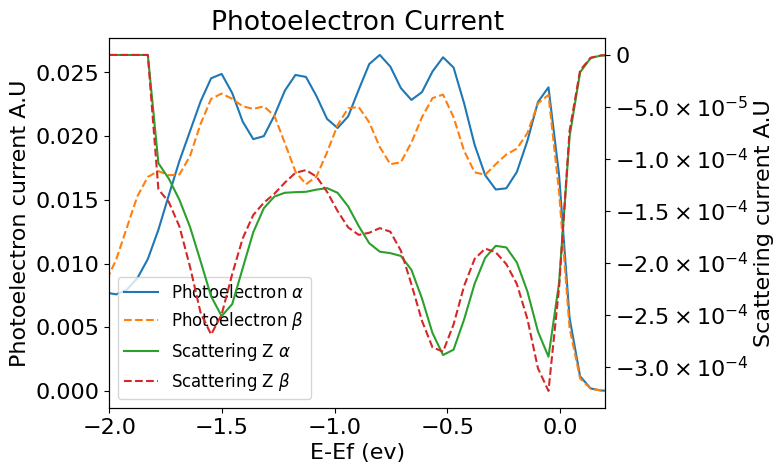

In [5]:
outputName = "CHARONCALC/CHO_PEX/LambdaSweep_0.04_EQ/CHO_CuSmall_PE0.04_Current_Z_Lambda1D/CHOPE"
name1 = "Photoelectron"
name2 = "Scattering Z"
OnlyShowLead = None

npzFile = np.load(outputName + "DiviE.npz")
ESpace = npzFile["ESpace"]
I1Alpha = npzFile["I1Alpha"]
I1Beta = npzFile["I1Beta"]
if "I2Alpha" in npzFile:
    I2Alpha = npzFile["I2Alpha"]
    I2Beta = npzFile["I2Beta"]
    twoLeads = True
else:
    twoLeads = False

import matplotlib as mpl
colors = mpl.rcParams['axes.prop_cycle']
if OnlyShowLead is None or OnlyShowLead == 1:
    ESpace = ESpace * ev - 5.9 + 0.15*ev # 5.9 eV is the photon energy, 0.080267 is the chemical potential
    lns1 = plt.plot(ESpace,np.sum(I1Alpha,axis=1),label=f"{name1} $\\alpha$",color="C0")
    lns2 = plt.plot(ESpace,np.sum(I1Beta,axis=1),label=f"{name1} $\\beta$",linestyle="dashed",color="C1")
ax1 = plt.gca()
if (twoLeads and (OnlyShowLead is None or OnlyShowLead == 2)):
    ax2 = ax1.twinx()
    lns3 = ax2.plot(ESpace,np.sum(I2Alpha,axis=1),label=f"{name2} $\\alpha$",color="C2")
    lns4 = ax2.plot(ESpace,np.sum(I2Beta,axis=1),label=f"{name2} $\\beta$",linestyle="dashed",color="C3")

lns = lns1+lns2 + lns3 + lns4
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc=3,fontsize=12)
plt.xlim(-2,0.2)

ax1.set_ylabel("Photoelectron current A.U")
ax2.set_ylabel("Scattering current A.U")
ax1.set_xlabel("E-Ef (ev)")
#1 AU of current is 6.6236182375082(72)×10−3 A
# plt.xlim(-1.2,0.2)
plt.title("Photoelectron Current")
ax2.yaxis.set_major_formatter(magicFormatter)
plt.savefig("LambdaSweep_0.04_EQ_CHO_CuSmall_PE0.04_Current_Z_Lambda1D_PE.png",dpi=400,bbox_inches="tight")

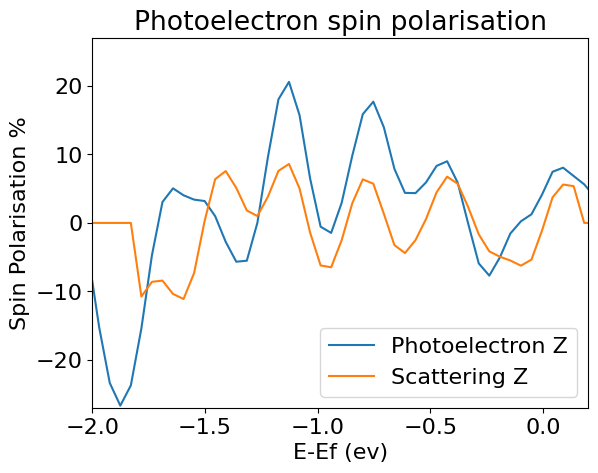

In [8]:
plotSpinPoldivCurrentE("CHARONCALC/CHO_PEX/LambdaSweep_0.04_EQ/CHO_CuSmall_PE0.04_Current_Z_Lambda1D/CHOPE","Photoelectron Z", "Scattering Z",True,True)
plt.ylim(-27,27)
plt.title("Photoelectron spin polarisation")
plt.savefig("LambdaSweep_0.04_EQ_CHO_CuSmall_PE0.04_Current_Z_Lambda1D_PESPINPOL.png",dpi=400,bbox_inches="tight")

In [ ]:
plotSpinPoldivCurrentE("CHARONCALC/CHO_PEX/LambdaSweep_0.04_EQ/CHO_CuSmall_PE0.04_Current_Z_Lambda1_0.1XScat_Z/CHOPE","Photoelectron Z", "Scattering Z")
plt.title("Photoelectron spin polarisation")
plt.savefig("LambdaSweep_0.04_EQ_CHO_CuSmall_PE0.04_Current_Z_Lambda1_0.1XScat_Z_PESPINPOL.png",dpi=400,bbox_inches="tight")
plt.close()

plotSpinPoldivCurrentE("CHARONCALC/CHO_PEX/LambdaSweep_0.04_EQ/CHO_CuSmall_PE0.04_Current_Z_Lambda1_0.1X_Z/CHOPE","Photoelectron Z", "Scattering Z")
plt.title("Photoelectron spin polarisation")
plt.savefig("LambdaSweep_0.04_EQ_CHO_CuSmall_PE0.04_Current_Z_Lambda1_0.1X_Z_PESPINPOL.png",dpi=400,bbox_inches="tight")
plt.close()

# plotSpinPoldivCurrentE("CHARONCALC/CHO_PEX/CHO_CuSmall_PE0.04_Current_LR_Z/CHOPE","Photoelectron Z", "Scattering Z")
# plt.title("Photoelectron spin polarisation")
# plt.savefig("CHO_CuSmall_PE0.04_Current_LR_Z_PESPINPOL.png",dpi=400,bbox_inches="tight")
# plt.close()

plotSpinPoldivCurrentE("CHARONCALC/CHO_PEX/LambdaSweep_0.04_EQ/CHO_CuSmall_0_PE0.04_Current_Z_Lambda1/CHOPE","Photoelectron Z", "Scattering Z")
plt.title("Photoelectron spin polarisation")
plt.savefig("LambdaSweep_0.04_EQ_CHO_CuSmall_0_PE0.04_Current_Z_Lambda1_PESPINPOL.png",dpi=400,bbox_inches="tight")
plt.close()

plotSpinPoldivCurrentE("CHARONCALC/CHO_PEX/LambdaSweep_0.04_EQ/CHO_CuSmall_0.04_PE0_Current_Z_Lambda1/CHOPE","Photoelectron Z", "Scattering Z")
plt.title("Photoelectron spin polarisation")
plt.savefig("LambdaSweep_0.04_EQ_CHO_CuSmall_0.04_PE0_Current_Z_Lambda1_PESPINPOL.png",dpi=400,bbox_inches="tight")
plt.close()

Net Polarisation:-0.9478372900825461


Text(0.5, 1.0, 'Electron Density on Atom')

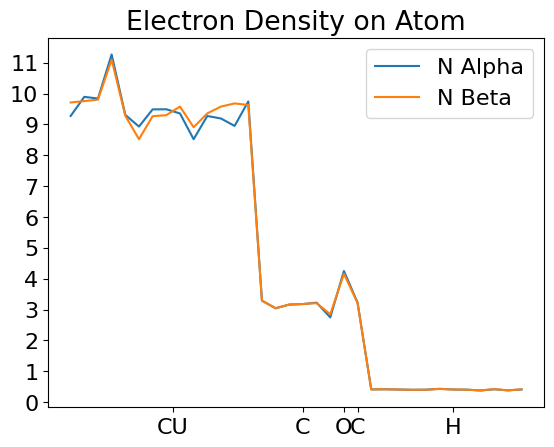

In [10]:
plotDensity("CHARONCALC/CHO_PEX/LambdaSweep_0.04_EQ/CHO_CuSmall_PE0.04_Current_Z_Lambda1D/CHO")
pos,Text = plt.xticks()
newPos = [7.5,17,20,21,28]
newText = ["CU","C","O","C","H"]
plt.xticks(newPos,newText)
plt.yticks(np.arange(0,12,step=1))
plt.title("Electron Density on Atom")
# plt.savefig("CHO_CuSmall_PE_0.04_NOSOC_DENSITY.png",dpi=400)

[np.float64(-0.31622776601683794), np.float64(-0.027825594022071243), np.float64(-0.002448436746822227), np.float64(-0.00021544346900318823), np.float64(-1.8957356524063752e-05), np.float64(-1.6681005372000591e-06), np.float64(-1.4677992676220674e-07), np.float64(-1.2915496650148827e-08), np.float64(-1.1364636663857243e-09), np.float64(-1e-10), np.float64(1e-10), np.float64(1.1364636663857243e-09), np.float64(1.2915496650148827e-08), np.float64(1.4677992676220706e-07), np.float64(1.6681005372000591e-06), np.float64(1.8957356524063752e-05), np.float64(0.00021544346900318867), np.float64(0.002448436746822229), np.float64(0.027825594022071257), np.float64(0.31622776601683794)]


Text(0, 0.5, 'E - Ef (ev)')

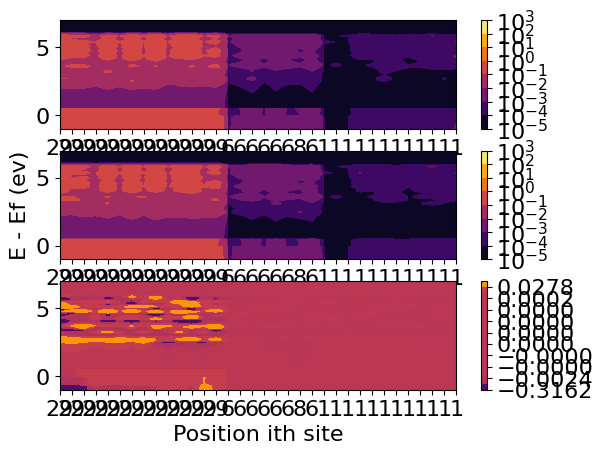

In [11]:
outputName = "CHARONCALC/CHO_PEX/LambdaSweep_0.04_EQ/CHO_CuSmall_PE0.04_Current_Z_Lambda1D/CHO"

npzFile = np.load(outputName + "ElectronSpectralDensity.npz",)
positions = npzFile["positions"]
linESpace = npzFile["linESpace"]
OrbLabels = npzFile["OrbLabels"]
E = npzFile["E"]
R = npzFile["R"]
nESW = npzFile["nESW"]
nE = npzFile["nE"]


E = E * ev + 0.15*ev

smallestValue = 1e-5#np.min(nE)
smallestValue = abs(smallestValue)

NAlpha = np.array([[nE[idx][2*r].real  if nE[idx][2*r].real > smallestValue else smallestValue  for r in positions] for idx in range(len(linESpace))]).T  
NBeta = np.array([[nE[idx][2*r+1].real if nE[idx][2*r+1].real > smallestValue else smallestValue for r in positions] for idx in range(len(linESpace))]).T  

fig, axs = plt.subplots(3)
#axs = [axs]
#print(f"minNAlpha:{np.min(NAlpha)}")
levels = list(-np.logspace(-0.5,-10,10)) + list(np.logspace(-10,-0.5,10))
print(levels)
img1 = axs[0].contourf(R, E, NAlpha, 100,locator=ticker.LogLocator(),cmap=plt.cm.inferno)
img2 = axs[1].contourf(R, E, NBeta, 100,locator=ticker.LogLocator(),cmap=plt.cm.inferno)
img3 = axs[2].contourf(R, E, (NAlpha-NBeta), 100,levels=levels,cmap=plt.cm.inferno)

axs[0].set_xticks(positions,OrbLabels)
axs[1].set_xticks(positions,OrbLabels)
axs[2].set_xticks(positions,OrbLabels)

axs[0].set_ylim(-1,7)
axs[1].set_ylim(-1,7)
axs[2].set_ylim(-1,7)

fig.colorbar(img1)
fig.colorbar(img2)
cbar = fig.colorbar(img3)

axs[2].set_xlabel("Position ith site")
axs[1].set_ylabel("E - Ef (ev)")

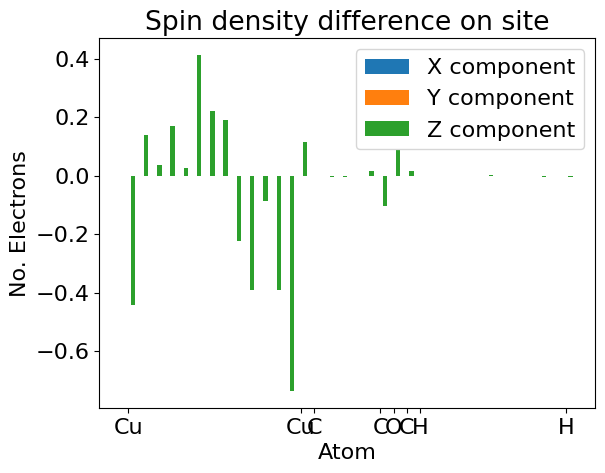

Net polarisation in copper-0.003597041205700303


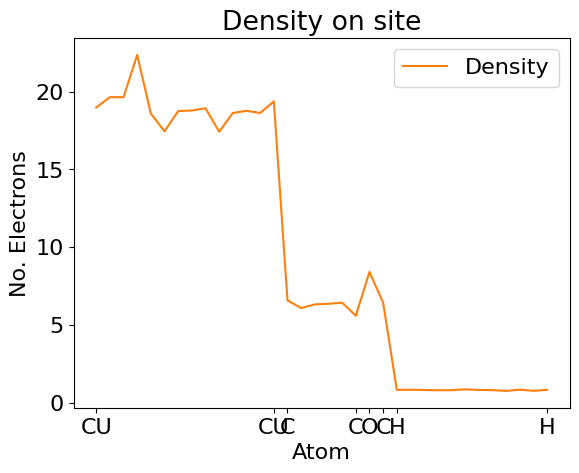

In [24]:
outputName = "CHARONCALC/CHO_PEX/LambdaSweep_0.04_EQ/CHO_CuSmall_PE0.04_Current_Z_Lambda1D/CHO"
PaulisigmaX = np.array([[0,1],[1,0]])
PaulisigmaY = np.array([[0,-1j],[1j,0]])
PaulisigmaZ = np.array([[1,0],[0,-1]])

sigmaX,sigmaY,sigmaZ = np.einsum("ix,xpq->ipq",[XDirection,YDirection,ZDirection],[PaulisigmaX,PaulisigmaY,PaulisigmaZ])
sigmaI = np.identity(2)



if not os.path.isfile(outputName + "ElectronSpinDensity.npz"):
    raise ValueError(f"Cannot find file{outputName + "ElectronSpinDensity.npz"}")
npzFile = np.load(outputName + "ElectronSpinDensity.npz")
compDensity = npzFile["compDensity"]
positions = npzFile["positions"]
OrbLabels = npzFile["OrbLabels"]
spatialProject = npzFile["spatialProject"]




xDensityDiff = np.real(np.einsum("qp,ipq -> i",sigmaX,compDensity))
yDensityDiff = np.real(np.einsum("qp,ipq -> i",sigmaY,compDensity))
zDensityDiff = np.real(np.einsum("qp,ipq -> i",sigmaZ,compDensity))
Density = np.real(np.einsum("qp,ipq -> i",sigmaI,compDensity))
if (spatialProject is None):
    spatialProject = np.identity(len(xDensityDiff))
    spatialInvProject = np.identity(len(xDensityDiff))
else:
    xDensityDiff = np.einsum("ji,j->i",spatialProject,xDensityDiff)
    yDensityDiff = np.einsum("ji,j->i",spatialProject,yDensityDiff)
    zDensityDiff = np.einsum("ji,j->i",spatialProject,zDensityDiff)
    Density = np.einsum("ji,j->i",spatialProject,Density)
    

ffig, ax1 = plt.subplots()


lns1 = ax1.bar(positions-1/3,xDensityDiff+1e-5,1/3,label="X component",color="#1f77b4")
lns2 = ax1.bar(positions,yDensityDiff+1e-5,1/3,label="Y component",color="#ff7f0e")
lns3 = ax1.bar(positions+1/3,zDensityDiff+1e-5,1/3,label="Z component",color="#2ca02c")

plt.xticks(positions,OrbLabels)
#ticks = [-4e-6,-2e-6,0,2e-6,4e-6,6e-6,8e-6]
#tickLabels = ["$-4\\times 10^{-6}$","$-2\\times 10^{-6}$","$0\\times 10^{-6}$","$2\\times 10^{-6}$","$4\\times 10^{-6}$","$6\\times 10^{-6}$","$8\\times 10^{-6}$",]
#ax2.set_yticks(ticks,tickLabels)
#plt.ylim(0,1.1)
lns = lns1+lns2+lns3
labs = [l.get_label() for l in lns]
# ax1.legend(lns, labs, loc=0)
Labels = ["Cu","Cu","C","C","O","C","H","H"]
plt.xticks([0,13,14,19,20,21,22,33],Labels)
plt.legend()
plt.title("Spin density difference on site")
ax1.set_ylabel("No. Electrons")


plt.xlabel("Atom")
plt.savefig("LambdaSweep_0.04_EQ_CHO_CuSmall_PE0.04_Current_Z_Lambda1D_SPINDENSITY.png",dpi=400,bbox_inches="tight")

#Density plot
plt.show()
plt.close()

fig, ax1 = plt.subplots()
lns2 = ax1.plot(positions,Density,label="Density",color="#ff7f0e")


plt.xticks(positions,OrbLabels)
#plt.ylim(0,1.1)
plt.legend()
Labels = ["CU","CU","C","C","O","C","H","H"]
plt.xticks([0,13,14,19,20,21,22,33],Labels)
plt.title("Density on site")
ax1.set_ylabel("No. Electrons")

plt.xlabel("Atom")
plt.savefig("LambdaSweep_0.04_EQ_CHO_CuSmall_PE0.04_Current_Z_Lambda1D_ELECDENSITY.png",dpi=400,bbox_inches="tight")
print(f"Net polarisation in copper{np.sum(zDensityDiff[0:14])/np.sum(Density[0:14])}")



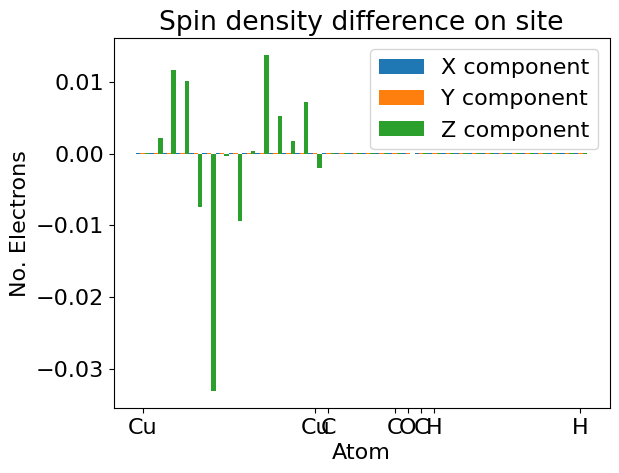

Net polarisation in copper0.0002665435406761637


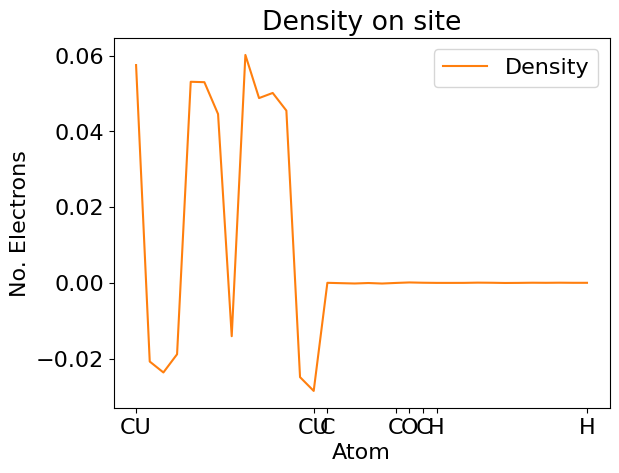

In [14]:
outputName = "CHARONCALC/CHO_PEX/LambdaSweep_0.04_EQ/CHO_CuSmall_PE0.04_Current_Z_Lambda1D/CHO"
PaulisigmaX = np.array([[0,1],[1,0]])
PaulisigmaY = np.array([[0,-1j],[1j,0]])
PaulisigmaZ = np.array([[1,0],[0,-1]])

sigmaX,sigmaY,sigmaZ = np.einsum("ix,xpq->ipq",[XDirection,YDirection,ZDirection],[PaulisigmaX,PaulisigmaY,PaulisigmaZ])
sigmaI = np.identity(2)



if not os.path.isfile(outputName + "ElectronSpinDensity.npz"):
    raise ValueError(f"Cannot find file{outputName + "ElectronSpinDensity.npz"}")
npzFile = np.load(outputName + "ElectronSpinDensity.npz")
positions = npzFile["positions"]
OrbLabels = npzFile["OrbLabels"]
spatialProject = npzFile["spatialProject"]
fullDensity =  np.load(outputName+"finalNonEqGn.npy")
#turn fulldensity into compdensity, a Nx2x2 array with just the 2x2 block diagonal elements
compDensity = np.zeros((fullDensity.shape[0]//2,2,2),dtype=np.complex128)
for i in range(compDensity.shape[0]):
    compDensity[i,0,0] = fullDensity[2*i,2*i]
    compDensity[i,0,1] = fullDensity[2*i,2*i+1]
    compDensity[i,1,0] = fullDensity[2*i+1,2*i]
    compDensity[i,1,1] = fullDensity[2*i+1,2*i+1]




xDensityDiff = np.real(np.einsum("qp,ipq -> i",sigmaX,compDensity))
yDensityDiff = np.real(np.einsum("qp,ipq -> i",sigmaY,compDensity))
zDensityDiff = np.real(np.einsum("qp,ipq -> i",sigmaZ,compDensity))
Density = np.real(np.einsum("qp,ipq -> i",sigmaI,compDensity))
if (spatialProject is None):
    spatialProject = np.identity(len(xDensityDiff))
    spatialInvProject = np.identity(len(xDensityDiff))
else:
    xDensityDiff = np.einsum("ji,j->i",spatialProject,xDensityDiff)
    yDensityDiff = np.einsum("ji,j->i",spatialProject,yDensityDiff)
    zDensityDiff = np.einsum("ji,j->i",spatialProject,zDensityDiff)
    Density = np.einsum("ji,j->i",spatialProject,Density)
    

ffig, ax1 = plt.subplots()
# xDensityDiff *= 10000
# yDensityDiff *= 10000
# zDensityDiff *= 10000

lns1 = ax1.bar(positions-1/3,xDensityDiff+1e-5,1/3,label="X component",color="#1f77b4")
lns2 = ax1.bar(positions,yDensityDiff+1e-5,1/3,label="Y component",color="#ff7f0e")
lns3 = ax1.bar(positions+1/3,zDensityDiff+1e-5,1/3,label="Z component",color="#2ca02c")

plt.xticks(positions,OrbLabels)
#ticks = [-4e-6,-2e-6,0,2e-6,4e-6,6e-6,8e-6]
#tickLabels = ["$-4\\times 10^{-6}$","$-2\\times 10^{-6}$","$0\\times 10^{-6}$","$2\\times 10^{-6}$","$4\\times 10^{-6}$","$6\\times 10^{-6}$","$8\\times 10^{-6}$",]
#ax2.set_yticks(ticks,tickLabels)
#plt.ylim(0,1.1)
lns = lns1+lns2+lns3
labs = [l.get_label() for l in lns]
# ax1.legend(lns, labs, loc=0)
Labels = ["Cu","Cu","C","C","O","C","H","H"]
plt.xticks([0,13,14,19,20,21,22,33],Labels)
plt.legend()
plt.title("Spin density difference on site")
ax1.set_ylabel("No. Electrons")


plt.xlabel("Atom")
plt.savefig("LambdaSweep_0.04_EQ_CHO_CuSmall_PE0.04_Current_Z_Lambda1D_NonEq_SPINDENSITY.png",dpi=400,bbox_inches="tight")

#Density plot
plt.show()
plt.close()

fig, ax1 = plt.subplots()
lns2 = ax1.plot(positions,Density,label="Density",color="#ff7f0e")


plt.xticks(positions,OrbLabels)
#plt.ylim(0,1.1)
plt.legend()
Labels = ["CU","CU","C","C","O","C","H","H"]
plt.xticks([0,13,14,19,20,21,22,33],Labels)
plt.title("Density on site")
ax1.set_ylabel("No. Electrons")

plt.xlabel("Atom")
plt.savefig("LambdaSweep_0.04_EQ_CHO_CuSmall_PE0.04_Current_Z_Lambda1D_NonEq_ELECDENSITY.png",dpi=400,bbox_inches="tight")
print(f"Net polarisation in copper{np.sum(zDensityDiff[0:14])/np.sum(Density[0:14])}")



In [15]:
from pyscf import gto, scf, lo
from pyscf.tools import cubegen

In [16]:
mol = gto.Mole()
mol.atom = '''
Cu        4.3232156232    2.7623989904   -0.0229852186
Cu        1.7941936425    3.1274949937    0.0456199935
Cu       -0.7348283382    3.4925909967    0.1142252057
Cu        0.2242924214    1.1381726716    0.3802287674
Cu        3.7124351618   -1.5813416568    0.5776271169
Cu        1.1834131811   -1.2162456537    0.6462323290
Cu        2.1425339407   -3.5706639788    0.9122358906
Cu        2.7533144021    0.7730766684    0.3116235552
Cu       -3.2638503189    3.8576870000    0.1828304177
Cu       -1.3456087997   -0.8511496504    0.7148375411
Cu       -3.8746307804   -0.4860536473    0.7834427533
Cu       -2.9155100208   -2.8404719724    1.0494463149
Cu       -2.3047295593    1.5032686747    0.4488339795
Cu       -0.3864880400   -3.2055679757    0.9808411028
C         0.8639660333   -1.2720675912   -4.9858407361
C         0.8063923118   -1.2572387891   -3.4433400896
C         0.4340672792   -2.6413184697   -2.8532218028
C        -1.0134736867   -3.0452715624   -3.1931902256
C        -2.0284398103   -1.9893316511   -2.6994071750
C        -1.6548100024   -0.5542836588   -3.0464918562
O        -2.5331736118    0.3004215224   -3.3225476121
C        -0.1860337499   -0.1817756943   -2.9243299090
H         1.5482156230   -2.0610246335   -5.3468181328
H        -0.1299052847   -1.4550528411   -5.4337160121
H         1.2250501878   -0.3036749225   -5.3739010036
H         1.8147821556   -0.9864109251   -3.0688542435
H         1.1416843819   -3.4078973422   -3.2231848794
H         0.5529293146   -2.6034176814   -1.7473398345
H        -1.1180467005   -3.1743849340   -4.2873400047
H        -1.2524090502   -4.0261782292   -2.7413106476
H        -3.0517035105   -2.1845938037   -3.0635477992
H        -2.0751755983   -2.0322931522   -1.5834155574
H        -0.0254293277    0.7989784691   -3.4046103131
H        -0.0033720926   -0.0405652585   -1.8303716361
    '''
mol.basis = 'lanl2dz'
mol.spin = 0
mol.ecp = 'lanl2dz'
mol.build()
nao = mol.nao
S_AO = mol.intor_symmetric("int1e_ovlp")
S_SO = np.zeros((nao*2,nao*2))
S_SO[1::2,1::2] = S_SO[::2,::2] = S_AO

ECP lanl2dz not found for  H
ECP lanl2dz not found for  O
ECP lanl2dz not found for  C


In [17]:
Gn = np.load("CHARONCALC/CHO_PEX/LambdaSweep_0.04_EQ/CHO_CuSmall_PE0.04_Current_Z_Lambda1D/CHOfinalGn.npy")
#Natural Orbitals
E,V = np.linalg.eig(Gn)
E = np.real(E)

In [ ]:
for i,occ in enumerate(E):
    if abs(occ) > 1e-5 and abs(occ) < 5e-1:    
        vec = V[:,i].reshape(-1,2)
        vec = np.linalg.norm(vec,axis=1)
        cubegen.orbital(mol, f"cube/LambdaSweep_0.04_EQ_CHO_CuSmall_PE0.04_Current_Z_LambdaSweep1D_{i}.cube", vec)

In [18]:
Gn = np.load("CHARONCALC/CHO_PEX/LambdaSweep_0.04_EQ/CHO_CuSmall_PE0.04_Current_Z_Lambda1D/CHOfinalGn.npy")

Gn = Gn@np.linalg.inv(S_SO)

PI = Gn[1::2,1::2] + Gn[0::2,0::2]
PX = Gn[0::2,1::2] + Gn[1::2,0::2]
PY = -1j*Gn[0::2,1::2] + 1j*Gn[1::2,0::2]
PZ = Gn[0::2,0::2] - Gn[1::2,1::2]

cubegen.density(mol, 'cube/spinPI.cube', PI,nx=150,ny=150,nz=150)
cubegen.density(mol, 'cube/spinPx.cube', PX,nx=150,ny=150,nz=150)
cubegen.density(mol, 'cube/spinPY.cube', PY,nx=150,ny=150,nz=150)
cubegen.density(mol, 'cube/spinPZ.cube', PZ,nx=150,ny=150,nz=150)

array([[[ 2.13866986e-10,  2.53660524e-10,  3.00385888e-10, ...,
         -3.80217568e-07, -3.28153458e-07, -2.77654616e-07],
        [ 2.24537326e-10,  2.66351791e-10,  3.15456728e-10, ...,
         -5.62723932e-07, -4.98370446e-07, -4.35940397e-07],
        [ 2.35153371e-10,  2.78980760e-10,  3.30456318e-10, ...,
         -7.75842438e-07, -6.96989340e-07, -6.20508506e-07],
        ...,
        [ 4.79689318e-09,  5.52740540e-09,  6.35860954e-09, ...,
         -2.88336299e-06, -2.50108236e-06, -2.14891822e-06],
        [ 4.66343877e-09,  5.37334528e-09,  6.18107543e-09, ...,
         -2.42484575e-06, -2.08795630e-06, -1.77743971e-06],
        [ 4.52707777e-09,  5.21598932e-09,  5.99981092e-09, ...,
         -2.00491846e-06, -1.70929084e-06, -1.43672241e-06]],

       [[ 2.29626898e-10,  2.72334337e-10,  3.22476825e-10, ...,
         -4.25110612e-07, -3.68603223e-07, -3.13810146e-07],
        [ 2.41194261e-10,  2.86090300e-10,  3.38809280e-10, ...,
         -6.27666177e-07, -5.57671034e

In [19]:
Gn = np.load("CHARONCALC/CHO_PEX/LambdaSweep_0.04_EQ/CHO_CuSmall_PE0.04_Current_Z_Lambda1D/CHOfinalNonEqGn.npy")
Gn = Gn@np.linalg.inv(S_SO)

PI = Gn[1::2,1::2] + Gn[0::2,0::2]
PX = Gn[0::2,1::2] + Gn[1::2,0::2]
PY = -1j*Gn[0::2,1::2] + 1j*Gn[1::2,0::2]
PZ = Gn[0::2,0::2] - Gn[1::2,1::2]

PX, PY, PZ = np.einsum("ix,xpq->ipq",[XDirection,YDirection,ZDirection],[PX,PY,PZ])
PZ*=1000

cubegen.density(mol, 'cube/spinCulledPI.cube', PI,nx=150,ny=150,nz=150)
cubegen.density(mol, 'cube/spinCulledPx.cube', PX,nx=150,ny=150,nz=150)
cubegen.density(mol, 'cube/spinCulledPY.cube', PY,nx=150,ny=150,nz=150)
cubegen.density(mol, 'cube/spinCulledPZ.cube', PZ,nx=150,ny=150,nz=150)

array([[[-5.24523326e-08, -6.15146355e-08, -7.20239721e-08, ...,
         -4.40665875e-05, -5.95114144e-05, -7.41548705e-05],
        [-5.71998404e-08, -6.70850845e-08, -7.85492127e-08, ...,
         -3.69464652e-05, -5.40564732e-05, -7.02981647e-05],
        [-6.22294416e-08, -7.29872145e-08, -8.54637913e-08, ...,
         -2.83722203e-05, -4.72672022e-05, -6.52232432e-05],
        ...,
        [-2.72931597e-08, -3.64005733e-08, -4.75728036e-08, ...,
          2.17018633e-04,  2.02867569e-04,  1.88947283e-04],
        [-9.69620679e-09, -1.59410715e-08, -2.38261581e-08, ...,
          2.22991204e-04,  2.08878005e-04,  1.94989226e-04],
        [ 6.67359548e-09,  3.11167136e-09, -1.68935689e-09, ...,
          2.27522614e-04,  2.13505276e-04,  1.99704973e-04]],

       [[-5.44731492e-08, -6.38890407e-08, -7.48093660e-08, ...,
         -3.50603682e-05, -5.14413464e-05, -6.69927834e-05],
        [-5.94590656e-08, -6.97396083e-08, -8.16632041e-08, ...,
         -2.69396698e-05, -4.50918278e

In [20]:
Gn = np.load("CHARONCALC/CHO_PEX/LambdaSweep_0.04_EQ/CHO_CuSmall_PE0.04_Current_Z_Lambda1D/CHOfinalNonEqGn.npy")
print(np.diagonal(Gn))

[ 2.55961838e-07+2.65080638e-10j  1.24376125e-07+1.97007789e-10j
  5.05718460e-04-7.75638654e-08j  2.71129920e-04-5.74019373e-08j
 -1.02327438e-03+2.08675703e-06j -1.41324694e-03+2.77861720e-06j
  2.52778915e-06-1.06704185e-10j  4.16985191e-06-9.89151643e-11j
  2.48683541e-06-1.47895343e-10j  3.25180302e-06-5.26384606e-11j
  2.03190542e-06-1.25682745e-11j  2.82552273e-06-2.48214597e-10j
  7.06935735e-04-2.90588112e-08j  1.18479280e-03-2.61237821e-07j
  7.15167387e-04-1.13574083e-07j  9.75294242e-04+5.03258757e-08j
  3.91026747e-04+8.72401526e-07j  7.78468497e-04+1.32148867e-07j
  7.63329697e-03+3.90743065e-06j  7.47540412e-03+1.06641486e-06j
  1.23673744e-02-1.60736662e-05j  1.19540200e-02-1.23871489e-05j
  7.45513074e-03-2.72608996e-05j  7.39804337e-03-2.62507598e-05j
  1.43798736e-05-2.51940176e-10j  1.37518757e-05-4.01046527e-10j
  7.60508788e-06-2.94922831e-10j  8.87379200e-06-3.93550543e-10j
  5.76966711e-06-1.59899396e-10j  6.12605921e-06-2.28235746e-10j
  1.18018846e-05-4.082965

In [21]:
E,V = np.linalg.eig(PI@S_AO)
print(np.real(E).min())

-6.840193221826557e-17


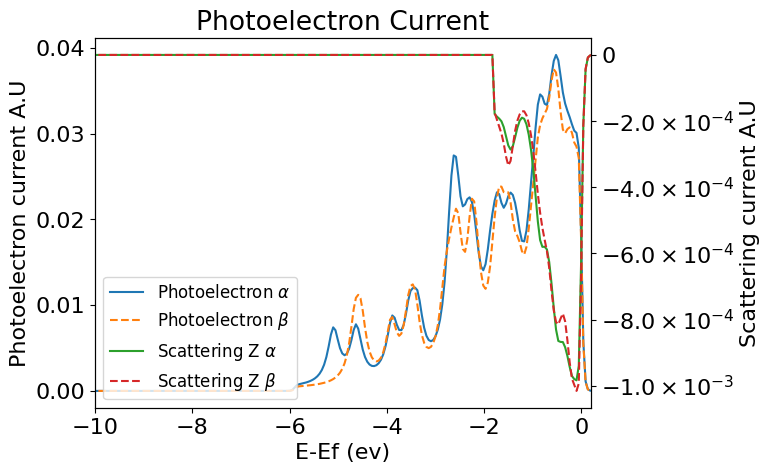

In [43]:
outputName = "CHARONCALC/CHO_PEX/LambdaSweep/CHO_CuSmall_PE0.04_Current_Z_Lambda1_partialConv/CHOPE"
name1 = "Photoelectron"
name2 = "Scattering Z"
OnlyShowLead = None

npzFile = np.load(outputName + "DiviE.npz")
ESpace = npzFile["ESpace"]
I1Alpha = npzFile["I1Alpha"]
I1Beta = npzFile["I1Beta"]
if "I2Alpha" in npzFile:
    I2Alpha = npzFile["I2Alpha"]
    I2Beta = npzFile["I2Beta"]
    twoLeads = True
else:
    twoLeads = False

import matplotlib as mpl
colors = mpl.rcParams['axes.prop_cycle']
if OnlyShowLead is None or OnlyShowLead == 1:
    ESpace = ESpace * ev - 5.9 + 0.15*ev # 5.9 eV is the photon energy, 0.080267 is the chemical potential
    lns1 = plt.plot(ESpace,np.sum(I1Alpha,axis=1),label=f"{name1} $\\alpha$",color="C0")
    lns2 = plt.plot(ESpace,np.sum(I1Beta,axis=1),label=f"{name1} $\\beta$",linestyle="dashed",color="C1")
ax1 = plt.gca()
if (twoLeads and (OnlyShowLead is None or OnlyShowLead == 2)):
    ax2 = ax1.twinx()
    lns3 = ax2.plot(ESpace,np.sum(I2Alpha,axis=1),label=f"{name2} $\\alpha$",color="C2")
    lns4 = ax2.plot(ESpace,np.sum(I2Beta,axis=1),label=f"{name2} $\\beta$",linestyle="dashed",color="C3")

lns = lns1+lns2 + lns3 + lns4
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc=3,fontsize=12)
plt.xlim(-10,0.2)

ax1.set_ylabel("Photoelectron current A.U")
ax2.set_ylabel("Scattering current A.U")
ax1.set_xlabel("E-Ef (ev)")
#1 AU of current is 6.6236182375082(72)×10−3 A
# plt.xlim(-1.2,0.2)
plt.title("Photoelectron Current")
ax2.yaxis.set_major_formatter(magicFormatter)
# plt.savefig("CHO_CuSmall_PE0.04_Current_Z_PE.png",dpi=400,bbox_inches="tight")

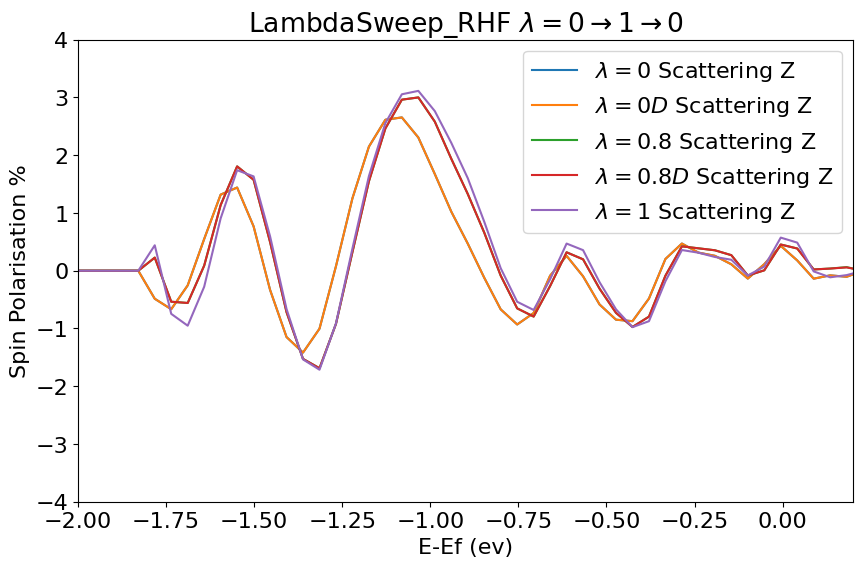

In [35]:
plotSpinPoldivCurrentE("CHARONCALC/CHO_PEX/LambdaSweep_RHF/CHO_CuSmall_PE0.04_Current_Z_Lambda0/CHOPE",r"$\lambda=0$ Photoelectron Z", r"$\lambda=0$ Scattering Z",False)
plotSpinPoldivCurrentE("CHARONCALC/CHO_PEX/LambdaSweep_RHF/CHO_CuSmall_PE0.04_Current_Z_Lambda0D/CHOPE",r"$\lambda=0D$ Photoelectron Z", r"$\lambda=0D$ Scattering Z",False)
plotSpinPoldivCurrentE("CHARONCALC/CHO_PEX/LambdaSweep_RHF/CHO_CuSmall_PE0.04_Current_Z_Lambda0.8/CHOPE",r"$\lambda=0.8$ Photoelectron Z", r"$\lambda=0.8$ Scattering Z",False)
plotSpinPoldivCurrentE("CHARONCALC/CHO_PEX/LambdaSweep_RHF/CHO_CuSmall_PE0.04_Current_Z_Lambda0.8D/CHOPE",r"$\lambda=0.8D$ Photoelectron Z", r"$\lambda=0.8D$ Scattering Z",False)
plotSpinPoldivCurrentE("CHARONCALC/CHO_PEX/LambdaSweep_RHF/CHO_CuSmall_PE0.04_Current_Z_Lambda1/CHOPE",r"$\lambda=1$ Photoelectron Z", r"$\lambda=1$ Scattering Z",False)
plt.ylim(-4,4)
plt.title(r"LambdaSweep_RHF $\lambda = 0 \rightarrow 1\rightarrow 0$")
fig = plt.gcf()
fig.set_size_inches(10, 6)
plt.savefig("LambdaSweep_RHF_CHO_CuSmall_PE0.04_Current_Z_SCATSPINPOL.png",dpi=400,bbox_inches="tight")

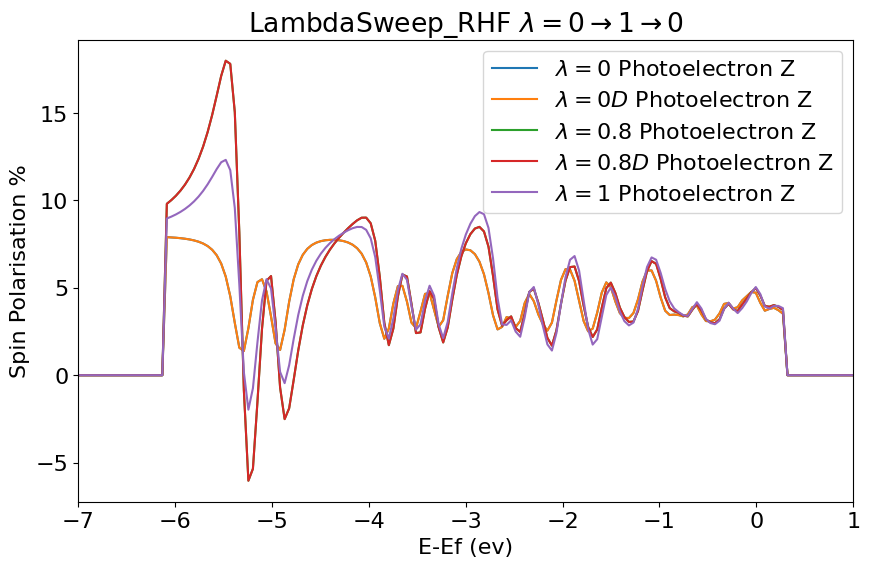

In [34]:
plotSpinPoldivCurrentE("CHARONCALC/CHO_PEX/LambdaSweep_RHF/CHO_CuSmall_PE0.04_Current_Z_Lambda0/CHOPE",r"$\lambda=0$ Photoelectron Z", r"$\lambda=0$ Scattering Z",True,False)
plotSpinPoldivCurrentE("CHARONCALC/CHO_PEX/LambdaSweep_RHF/CHO_CuSmall_PE0.04_Current_Z_Lambda0D/CHOPE",r"$\lambda=0D$ Photoelectron Z", r"$\lambda=0D$ Scattering Z",True,False)
plotSpinPoldivCurrentE("CHARONCALC/CHO_PEX/LambdaSweep_RHF/CHO_CuSmall_PE0.04_Current_Z_Lambda0.8/CHOPE",r"$\lambda=0.8$ Photoelectron Z", r"$\lambda=0.8$ Scattering Z",True,False)
plotSpinPoldivCurrentE("CHARONCALC/CHO_PEX/LambdaSweep_RHF/CHO_CuSmall_PE0.04_Current_Z_Lambda0.8D/CHOPE",r"$\lambda=0.8D$ Photoelectron Z", r"$\lambda=0.8D$ Scattering Z",True,False)
plotSpinPoldivCurrentE("CHARONCALC/CHO_PEX/LambdaSweep_RHF/CHO_CuSmall_PE0.04_Current_Z_Lambda1/CHOPE",r"$\lambda=1$ Photoelectron Z", r"$\lambda=1$ Scattering Z",True,False)
# plt.ylim(-4,4)
plt.xlim(-7,1)
plt.title(r"LambdaSweep_RHF $\lambda = 0 \rightarrow 1\rightarrow 0$")
fig = plt.gcf()
fig.set_size_inches(10, 6)
plt.savefig("LambdaSweep_RHF_CHO_CuSmall_PE0.04_Current_Z_PESPINPOL.png",dpi=400,bbox_inches="tight")

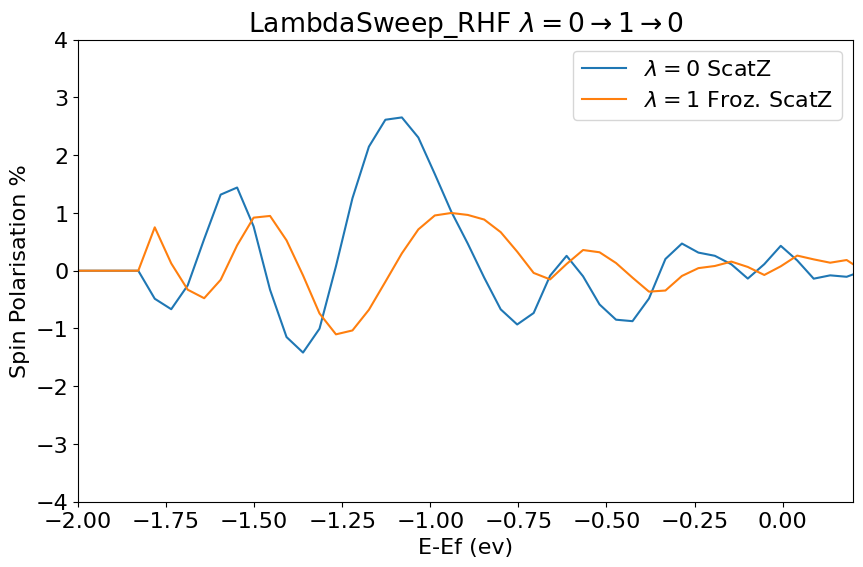

In [2]:
plotSpinPoldivCurrentE("CHARONCALC/CHO_PEX/LambdaSweep_RHF/CHO_CuSmall_PE0.04_Current_Z_Lambda0/CHOPE",r"$\lambda=0$ PEZ", r"$\lambda=0$ ScatZ",False)
plotSpinPoldivCurrentE("CHARONCALC/CHO_PEX/LambdaSweep_RHF/CHO_CuSmall_PE0.04_Current_Z_Lambda1_FrozL0Density/CHOPE",r"$\lambda=1$ Froz. PEZ", r"$\lambda=1$ Froz. ScatZ",False)
plt.ylim(-4,4)
plt.title(r"LambdaSweep_RHF $\lambda = 0 \rightarrow 1\rightarrow 0$")
fig = plt.gcf()
fig.set_size_inches(10, 6)
# plt.savefig("LambdaSweep_RHF_CHO_CuSmall_PE0.04_Current_Z_SCATSPINPOL.png",dpi=400,bbox_inches="tight")

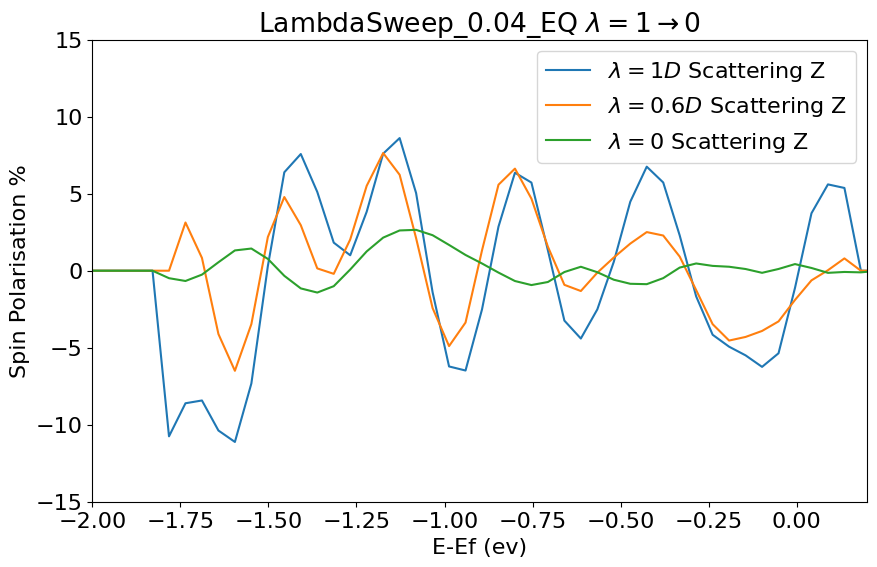

In [22]:
plotSpinPoldivCurrentE("CHARONCALC/CHO_PEX/LambdaSweep_0.04_EQ/CHO_CuSmall_PE0.04_Current_Z_Lambda1D/CHOPE",r"$\lambda=1D$ Photoelectron Z", r"$\lambda=1D$ Scattering Z",False)
# plotSpinPoldivCurrentE("CHARONCALC/CHO_PEX/LambdaSweep_0.04_EQ/CHO_CuSmall_PE0.04_Current_Z_Lambda0.8D/CHOPE",r"$\lambda=0.8D$ Photoelectron Z", r"$\lambda=0.8D$ Scattering Z",False)
plotSpinPoldivCurrentE("CHARONCALC/CHO_PEX/LambdaSweep_0.04_EQ/CHO_CuSmall_PE0.04_Current_Z_Lambda0.6D/CHOPE",r"$\lambda=0.6D$ Photoelectron Z", r"$\lambda=0.6D$ Scattering Z",False)
# plotSpinPoldivCurrentE("CHARONCALC/CHO_PEX/LambdaSweep_0.04_EQ/CHO_CuSmall_PE0.04_Current_Z_Lambda0.4D/CHOPE",r"$\lambda=0.4D$ Photoelectron Z", r"$\lambda=0.4D$ Scattering Z",False)
# plotSpinPoldivCurrentE("CHARONCALC/CHO_PEX/LambdaSweep_0.04_EQ/CHO_CuSmall_PE0.04_Current_Z_Lambda0.2D/CHOPE",r"$\lambda=0.2D$ Photoelectron Z", r"$\lambda=0.2D$ Scattering Z",False)
plotSpinPoldivCurrentE("CHARONCALC/CHO_PEX/LambdaSweep_0.04_EQ/CHO_CuSmall_PE0.04_Current_Z_Lambda0/CHOPE",r"$\lambda=0$ Photoelectron Z", r"$\lambda=0$ Scattering Z",False)

plt.ylim(-15,15)
plt.title(r"LambdaSweep_0.04_EQ $\lambda = 1 \rightarrow 0$")
fig = plt.gcf()
fig.set_size_inches(10, 6)
plt.savefig("LambdaSweep_0.04_EQ_CHO_CuSmall_PE0.04_Current_Z_SCATSPINPOL_Down.png",dpi=400,bbox_inches="tight")

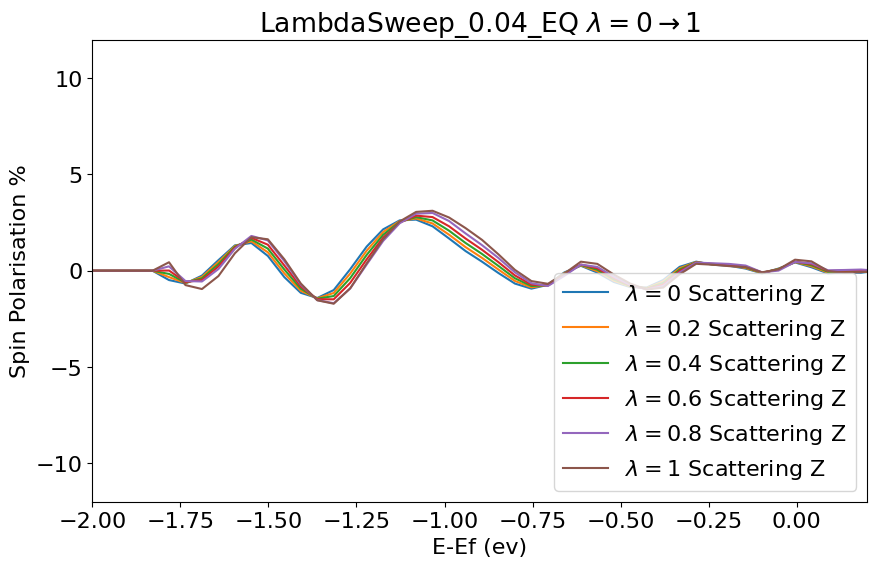

In [32]:
plotSpinPoldivCurrentE("CHARONCALC/CHO_PEX/LambdaSweep_0.04_EQ/CHO_CuSmall_PE0.04_Current_Z_Lambda0/CHOPE",r"$\lambda=0$ Photoelectron Z", r"$\lambda=0$ Scattering Z",False)
plotSpinPoldivCurrentE("CHARONCALC/CHO_PEX/LambdaSweep_0.04_EQ/CHO_CuSmall_PE0.04_Current_Z_Lambda0.2/CHOPE",r"$\lambda=0.2$ Photoelectron Z", r"$\lambda=0.2$ Scattering Z",False)
plotSpinPoldivCurrentE("CHARONCALC/CHO_PEX/LambdaSweep_0.04_EQ/CHO_CuSmall_PE0.04_Current_Z_Lambda0.4/CHOPE",r"$\lambda=0.4$ Photoelectron Z", r"$\lambda=0.4$ Scattering Z",False)
plotSpinPoldivCurrentE("CHARONCALC/CHO_PEX/LambdaSweep_0.04_EQ/CHO_CuSmall_PE0.04_Current_Z_Lambda0.6/CHOPE",r"$\lambda=0.6$ Photoelectron Z", r"$\lambda=0.6$ Scattering Z",False)
plotSpinPoldivCurrentE("CHARONCALC/CHO_PEX/LambdaSweep_0.04_EQ/CHO_CuSmall_PE0.04_Current_Z_Lambda0.8/CHOPE",r"$\lambda=0.8$ Photoelectron Z", r"$\lambda=0.8$ Scattering Z",False)
plotSpinPoldivCurrentE("CHARONCALC/CHO_PEX/LambdaSweep_0.04_EQ/CHO_CuSmall_PE0.04_Current_Z_Lambda1/CHOPE",r"$\lambda=1$ Photoelectron Z", r"$\lambda=1$ Scattering Z",False)

plt.ylim(-12,12)
plt.title(r"LambdaSweep_0.04_EQ $\lambda = 0 \rightarrow 1$")
fig = plt.gcf()
fig.set_size_inches(10, 6)
plt.savefig("LambdaSweep_0.04_EQ_CHO_CuSmall_PE0.04_Current_Z_SCATSPINPOL_Up.png",dpi=400,bbox_inches="tight")

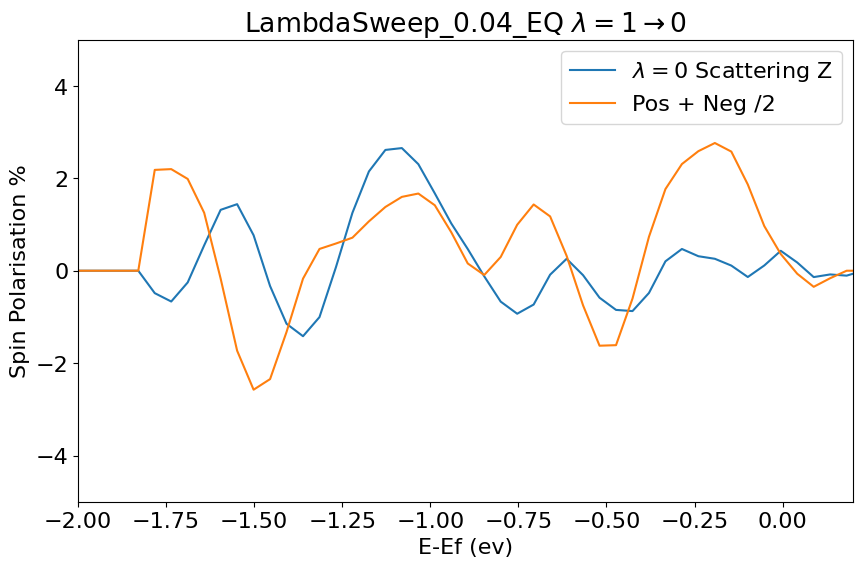

In [23]:
plotSpinPoldivCurrentE("CHARONCALC/CHO_PEX/LambdaSweep_0.04_EQ/CHO_CuSmall_PE0.04_Current_Z_Lambda0/CHOPE",r"$\lambda=0$ Photoelectron Z", r"$\lambda=0$ Scattering Z",False)
outputName1 = "CHARONCALC/CHO_PEX/LambdaSweep_0.04_EQ/CHO_CuSmall_PE0.04_Current_Z_Lambda1D/CHOPE"
outputName2 = "CHARONCALC/CHO_PEX/LambdaSweep_0.04_EQ/CHO_CuSmall_PE0.04_Current_Z_Lambda1D_Flipped/CHOPE"
label2 = r"Pos + Neg /2"
PlotI1 = False
PlotI2 = True
#Spin difference plot
    
if not os.path.isfile(outputName1 + "DiviE.npz"):
    print(f"Cannot find file{outputName1 + "DiviE.npz"}")
npzFile1 = np.load(outputName1 + "DiviE.npz")
ESpace = npzFile1["ESpace"]
ESpace = ESpace * ev - 5.9 + 0.15*ev
I2Alpha1 = npzFile1["I2Alpha"]
I2Beta1 = npzFile1["I2Beta"]

npzFile2 = np.load(outputName2 + "DiviE.npz")

I2Alpha2 = npzFile2["I2Alpha"]
I2Beta2 = npzFile2["I2Beta"]



I2Sum1 = np.sum(I2Alpha1+I2Beta1,axis=1)
I2Polarisation1  = np.zeros_like(I2Sum1)
np.divide(np.sum(I2Alpha1-I2Beta1,axis=1),I2Sum1,out=I2Polarisation1,where=np.abs(I2Sum1) > 1e-6)

I2Sum2 = np.sum(I2Alpha2+I2Beta2,axis=1)
I2Polarisation2  = np.zeros_like(I2Sum2)
np.divide(np.sum(I2Alpha2-I2Beta2,axis=1),I2Sum2,out=I2Polarisation2,where=np.abs(I2Sum2) > 1e-6)

plt.plot(ESpace,50*(I2Polarisation1 + I2Polarisation2),label=label2)
plt.ylabel("Spin Polarisation %")
plt.xlim(-2,0.2)
plt.xlabel("E-Ef (ev)")

plt.legend()

plt.ylim(-5,5)
plt.title(r"LambdaSweep_0.04_EQ $\lambda = 1 \rightarrow 0$")
fig = plt.gcf()
fig.set_size_inches(10, 6)
# plt.savefig("LambdaSweep_0.04_EQ_CHO_CuSmall_PE0.04_Current_Z_SCATSPINPOL_Down.png",dpi=400,bbox_inches="tight")

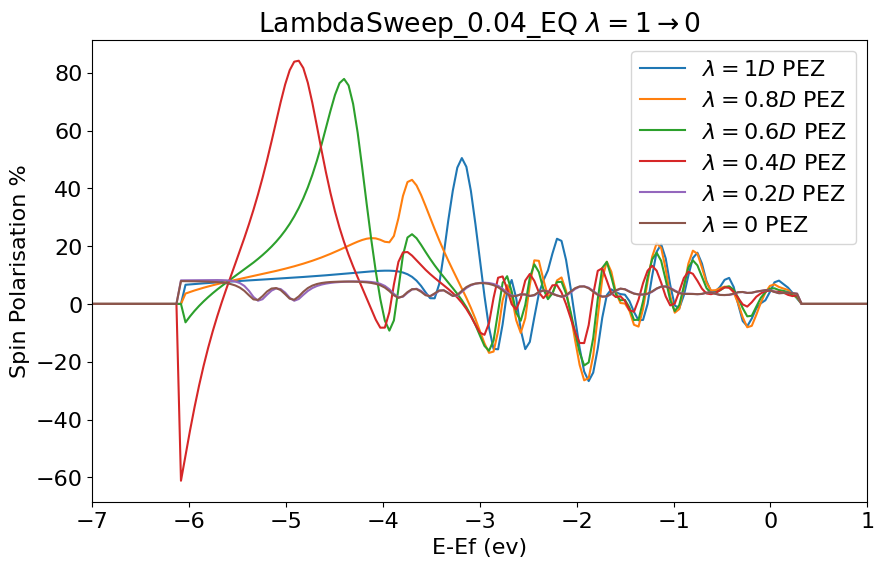

In [31]:
plotSpinPoldivCurrentE("CHARONCALC/CHO_PEX/LambdaSweep_0.04_EQ/CHO_CuSmall_PE0.04_Current_Z_Lambda1D/CHOPE",r"$\lambda=1D$ PEZ", r"$\lambda=1D$ Scattering Z",True,False)
plotSpinPoldivCurrentE("CHARONCALC/CHO_PEX/LambdaSweep_0.04_EQ/CHO_CuSmall_PE0.04_Current_Z_Lambda0.8D/CHOPE",r"$\lambda=0.8D$ PEZ", r"$\lambda=0.8D$ Scattering Z",True,False)
plotSpinPoldivCurrentE("CHARONCALC/CHO_PEX/LambdaSweep_0.04_EQ/CHO_CuSmall_PE0.04_Current_Z_Lambda0.6D/CHOPE",r"$\lambda=0.6D$ PEZ", r"$\lambda=0.6D$ Scattering Z",True,False)
plotSpinPoldivCurrentE("CHARONCALC/CHO_PEX/LambdaSweep_0.04_EQ/CHO_CuSmall_PE0.04_Current_Z_Lambda0.4D/CHOPE",r"$\lambda=0.4D$ PEZ", r"$\lambda=0.4D$ Scattering Z",True,False)
plotSpinPoldivCurrentE("CHARONCALC/CHO_PEX/LambdaSweep_0.04_EQ/CHO_CuSmall_PE0.04_Current_Z_Lambda0.2D/CHOPE",r"$\lambda=0.2D$ PEZ", r"$\lambda=0.2D$ Scattering Z",True,False)
plotSpinPoldivCurrentE("CHARONCALC/CHO_PEX/LambdaSweep_0.04_EQ/CHO_CuSmall_PE0.04_Current_Z_Lambda0/CHOPE",r"$\lambda=0$ PEZ", r"$\lambda=0$ Scattering Z",True,False)

# plt.ylim(-10,10)
plt.xlim(-7,1)
plt.title(r"LambdaSweep_0.04_EQ $\lambda = 1 \rightarrow 0$")
plt.legend(loc='upper right')
fig = plt.gcf()
fig.set_size_inches(10, 6)
plt.savefig("LambdaSweep_0.04_EQ_CHO_CuSmall_PE0.04_Current_Z_PESPINPOL_Down.png",dpi=400,bbox_inches="tight")


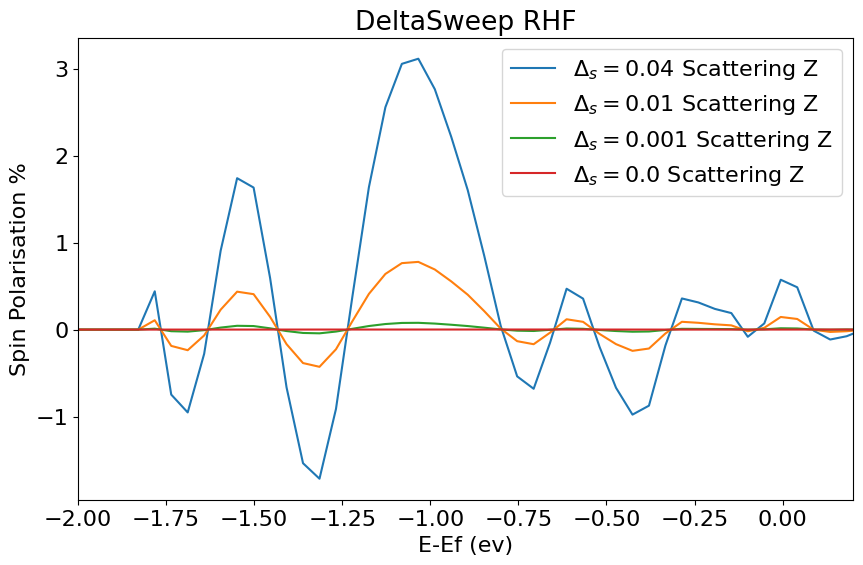

In [30]:
plotSpinPoldivCurrentE("CHARONCALC/CHO_PEX/LambdaSweep_RHF/CHO_CuSmall_PE0.04_Current_Z_Lambda1/CHOPE",r"$\Delta_s=0.04$ Photoelectron Z", r"$\Delta_s=0.04$ Scattering Z",False)
plotSpinPoldivCurrentE("CHARONCALC/CHO_PEX/LambdaSweep_RHF/CHO_CuSmall_PE0.01_Current_Z_Lambda1/CHOPE",r"$\Delta_s=0.01$ Photoelectron Z", r"$\Delta_s=0.01$ Scattering Z",False)
plotSpinPoldivCurrentE("CHARONCALC/CHO_PEX/LambdaSweep_RHF/CHO_CuSmall_PE0.001_Current_Z_Lambda1/CHOPE",r"$\Delta_s=0.001$ Photoelectron Z", r"$\Delta_s=0.001$ Scattering Z",False)
plotSpinPoldivCurrentE("CHARONCALC/CHO_PEX/LambdaSweep_RHF/CHO_CuSmall_PE0.0_Current_Z_Lambda1/CHOPE",r"$\Delta_s=0.0$ Photoelectron Z", r"$\Delta_s=0.0$ Scattering Z",False)

# plt.ylim(-15,15)
plt.title(r"DeltaSweep RHF")
fig = plt.gcf()
fig.set_size_inches(10, 6)
plt.savefig("LambdaSweep_RHF_CHO_CuSmall_DeltaSweep_Current_Z_SCATSPINPOL.png",dpi=400,bbox_inches="tight")

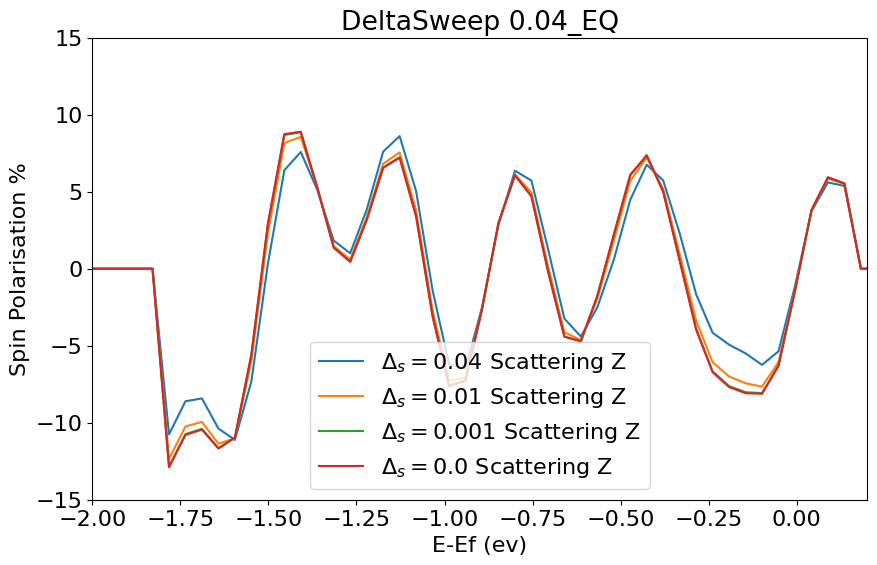

In [29]:
plotSpinPoldivCurrentE("CHARONCALC/CHO_PEX/LambdaSweep_0.04_EQ/CHO_CuSmall_PE0.04_Current_Z_Lambda1D/CHOPE",r"$\Delta_s=0.04$ Photoelectron Z", r"$\Delta_s=0.04$ Scattering Z",False)
plotSpinPoldivCurrentE("CHARONCALC/CHO_PEX/LambdaSweep_0.04_EQ/CHO_CuSmall_PE0.01_Current_Z_Lambda1D/CHOPE",r"$\Delta_s=0.01$ Photoelectron Z", r"$\Delta_s=0.01$ Scattering Z",False)
plotSpinPoldivCurrentE("CHARONCALC/CHO_PEX/LambdaSweep_0.04_EQ/CHO_CuSmall_PE0.001_Current_Z_Lambda1D/CHOPE",r"$\Delta_s=0.001$ Photoelectron Z", r"$\Delta_s=0.001$ Scattering Z",False)
plotSpinPoldivCurrentE("CHARONCALC/CHO_PEX/LambdaSweep_0.04_EQ/CHO_CuSmall_PE0.0_Current_Z_Lambda1D/CHOPE",r"$\Delta_s=0.0$ Photoelectron Z", r"$\Delta_s=0.0$ Scattering Z",False)

plt.ylim(-15,15)
plt.title(r"DeltaSweep 0.04_EQ")
fig = plt.gcf()
fig.set_size_inches(10, 6)
plt.savefig("LambdaSweep_0.04_EQ_CHO_CuSmall_DeltaSweep_Current_Z_SCATSPINPOL.png",dpi=400,bbox_inches="tight")